In [1]:
!pip install -q xgboost scikit-learn pandas numpy matplotlib seaborn


Dataset already extracted.
multimodal-gas-data/
  zkwgkjkjn9-2/
    Gas Sensors Measurements/
    Thermal Camera Images/
      Smoke/
      Perfume/
      Sample Thermal Camera Images/
        Smoke/
        Perfume/
        NoGas/
        Mixture/
      NoGas/
      Mixture/
Found CSV: /kaggle/input/datasets/rohanprabhakar1103/multimodal-gas-data/zkwgkjkjn9-2/Gas Sensors Measurements/Gas_Sensors_Measurements.csv

Shape: (6400, 10)

Columns: ['Serial Number', 'MQ2', 'MQ3', 'MQ5', 'MQ6', 'MQ7', 'MQ8', 'MQ135', 'Gas', 'Corresponding Image Name']

First 5 rows:
=== Dataset Overview ===
Total samples: 6400

Columns: ['Serial Number', 'MQ2', 'MQ3', 'MQ5', 'MQ6', 'MQ7', 'MQ8', 'MQ135', 'Gas', 'Corresponding Image Name']

Label column: Gas
Sensor columns: ['MQ2', 'MQ3', 'MQ5', 'MQ6', 'MQ7', 'MQ8', 'MQ135']
Dropping: ['Serial Number', 'Corresponding Image Name']

Class distribution:
Gas
NoGas      1600
Perfume    1600
Smoke      1600
Mixture    1600
Name: count, dtype: int64

First 5 rows:
   

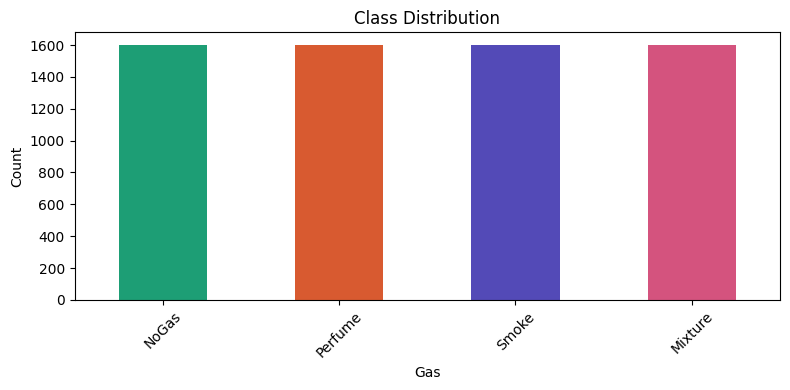

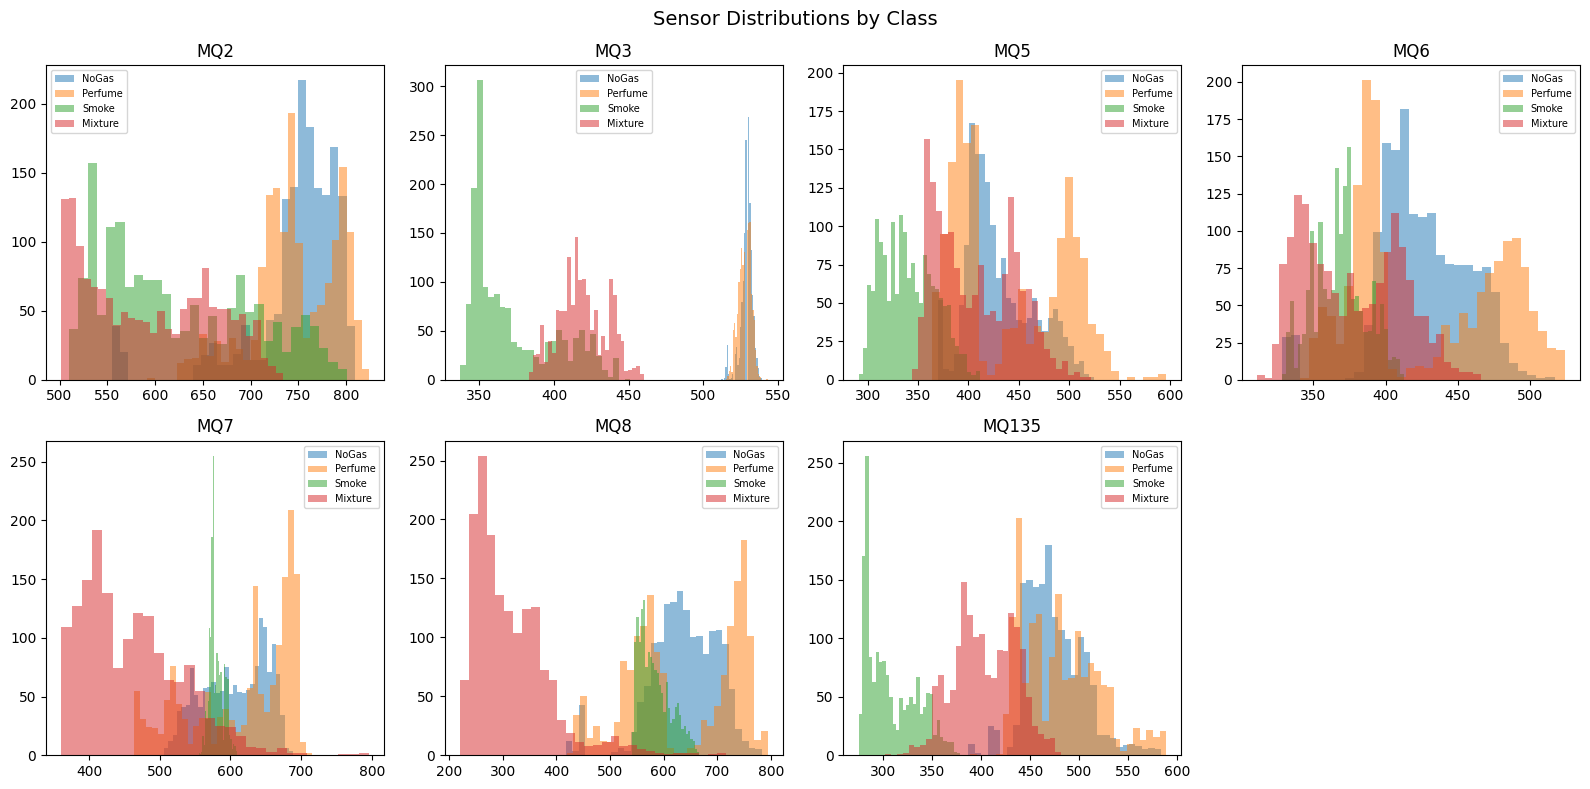

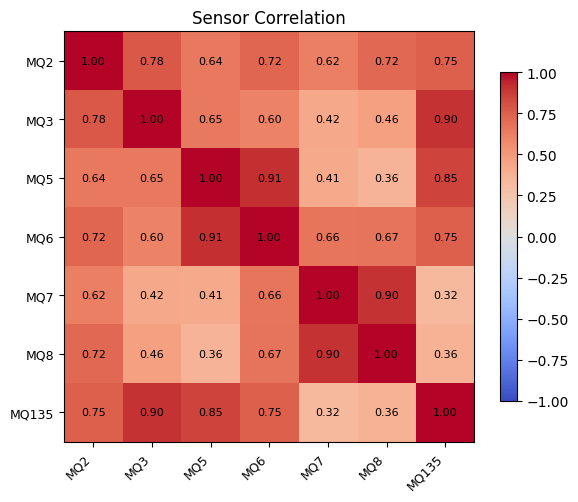

Classes: ['Mixture', 'NoGas', 'Perfume', 'Smoke']
Features shape: (6400, 7)
Labels shape: (6400,)

Train: 4480 samples
Val:   960 samples
Test:  960 samples
[0]	validation_0-mlogloss:1.21850
[20]	validation_0-mlogloss:0.23566
[40]	validation_0-mlogloss:0.11094
[60]	validation_0-mlogloss:0.08256
[80]	validation_0-mlogloss:0.07276
[100]	validation_0-mlogloss:0.06791
[120]	validation_0-mlogloss:0.06409
[140]	validation_0-mlogloss:0.06287
[160]	validation_0-mlogloss:0.06208
[180]	validation_0-mlogloss:0.06238
[199]	validation_0-mlogloss:0.06162

=== XGBoost Results ===
Accuracy: 0.9771

Classification Report:
              precision    recall  f1-score   support

     Mixture       1.00      1.00      1.00       240
       NoGas       0.94      0.97      0.95       240
     Perfume       0.97      0.94      0.95       240
       Smoke       1.00      1.00      1.00       240

    accuracy                           0.98       960
   macro avg       0.98      0.98      0.98       960
weighte

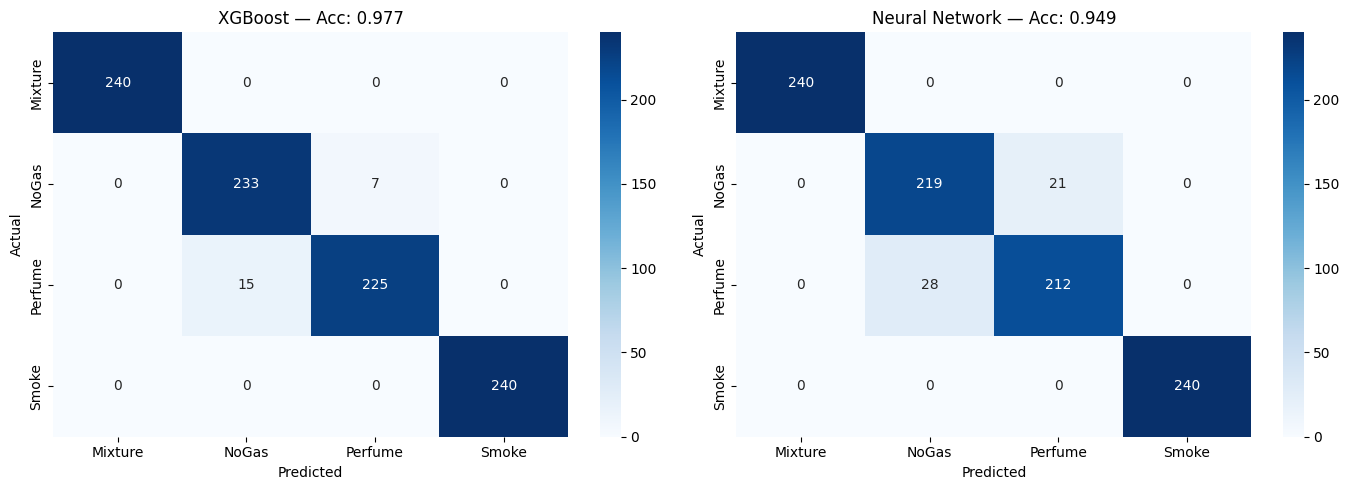

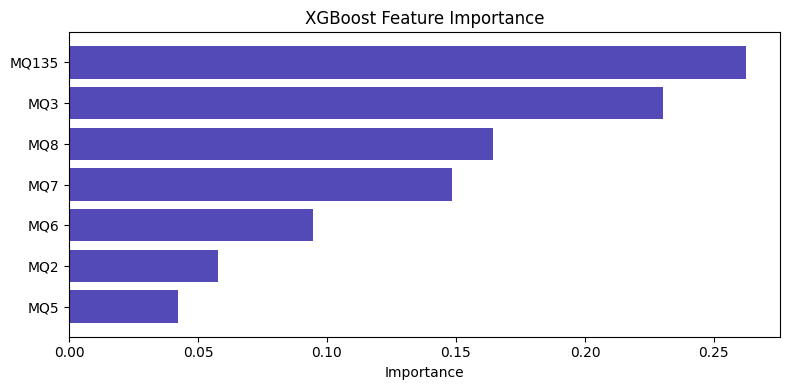

Best model: XGBoost (0.9771 accuracy)

Saved:
  gas_classifier.pkl   — trained model
  scaler.pkl           — StandardScaler
  label_encoder.pkl    — LabelEncoder
  sensor_columns.txt   — feature column order


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All artifacts downloaded. These go into your Akka project's resources folder.


In [2]:

# %%
import os
import zipfile

DATA_DIR = '/kaggle/input/datasets/rohanprabhakar1103/multimodal-gas-data'
ZIP_PATH = None

# Check if already extracted
if os.path.exists(DATA_DIR):
    print("Dataset already extracted.")
else:
    # Look for the ZIP in common locations
    possible_zips = [
        "zkwgkjkjn9-2.zip",
        "MultimodalGasData.zip",
        "archive.zip",
    ]
    # Also check for any zip in current dir
    all_zips = [f for f in os.listdir('.') if f.endswith('.zip')]
    possible_zips = list(set(possible_zips + all_zips))

    for z in possible_zips:
        if os.path.exists(z):
            ZIP_PATH = z
            break

    if ZIP_PATH is None:
        # Upload via Colab
        from google.colab import files
        print("No ZIP found. Upload the dataset ZIP from Mendeley:")
        print("https://data.mendeley.com/datasets/zkwgkjkjn9/2")
        uploaded = files.upload()
        ZIP_PATH = list(uploaded.keys())[0]

    print(f"Extracting {ZIP_PATH}...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(DATA_DIR)
    print("Done!")

# List what we got
for root, dirs, files in os.walk(DATA_DIR):
    level = root.replace(DATA_DIR, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:
        subindent = ' ' * 2 * (level + 1)
        for f in files[:10]:
            print(f'{subindent}{f}')
        if len(files) > 10:
            print(f'{subindent}... and {len(files) - 10} more files')

# %% [markdown]
# ## 3. Load and explore the sensor CSV data

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Find the CSV file(s) in the dataset
csv_files = []
for root, dirs, files in os.walk(DATA_DIR):
    for f in files:
        if f.endswith('.csv'):
            csv_files.append(os.path.join(root, f))
            print(f"Found CSV: {os.path.join(root, f)}")

# Load the first CSV (sensor data)
df = pd.read_csv(csv_files[0])
print(f"\nShape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst 5 rows:")
df.head()

# %%
# Basic stats
print("=== Dataset Overview ===")
print(f"Total samples: {len(df)}")
print(f"\nColumns: {list(df.columns)}")

# Set columns explicitly based on dataset structure
label_col = 'Gas'
sensor_cols = ['MQ2', 'MQ3', 'MQ5', 'MQ6', 'MQ7', 'MQ8', 'MQ135']
drop_cols = ['Serial Number', 'Corresponding Image Name']

print(f"\nLabel column: {label_col}")
print(f"Sensor columns: {sensor_cols}")
print(f"Dropping: {drop_cols}")
print(f"\nClass distribution:")
print(df[label_col].value_counts())
print(f"\nFirst 5 rows:")
print(df[sensor_cols + [label_col]].head())

# %%
# Visualize class distribution
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
df[label_col].value_counts().plot(kind='bar', ax=ax, color=['#1D9E75', '#D85A30', '#534AB7', '#D4537E'])
ax.set_title('Class Distribution')
ax.set_ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(sensor_cols[:7]):
    for cls in df[label_col].unique():
        subset = df[df[label_col] == cls][col]
        axes[i].hist(subset, alpha=0.5, label=str(cls), bins=30)
    axes[i].set_title(col)
    axes[i].legend(fontsize=7)

# Hide unused subplot
if len(sensor_cols) < 8:
    axes[7].set_visible(False)

plt.suptitle('Sensor Distributions by Class', fontsize=14)
plt.tight_layout()
plt.show()

# %%
# Correlation heatmap (lightweight version)
fig, ax = plt.subplots(figsize=(6, 5))
corr = df[sensor_cols].corr()
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(sensor_cols)))
ax.set_yticks(range(len(sensor_cols)))
ax.set_xticklabels(sensor_cols, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(sensor_cols, fontsize=9)
for i in range(len(sensor_cols)):
    for j in range(len(sensor_cols)):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=8)
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Sensor Correlation')
plt.tight_layout()
plt.show()

# %% [markdown]
# ## 4. Prepare data for training

# %%
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Features = sensor readings, Label = gas class
X = df[sensor_cols].values
le = LabelEncoder()
y = le.fit_transform(df[label_col])

print(f"Classes: {list(le.classes_)}")
print(f"Features shape: {X.shape}")
print(f"Labels shape: {y.shape}")

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split: 70% train, 15% val, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"\nTrain: {X_train.shape[0]} samples")
print(f"Val:   {X_val.shape[0]} samples")
print(f"Test:  {X_test.shape[0]} samples")

# %% [markdown]
# ## 5. Train XGBoost classifier

# %%
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Train XGBoost
model_xgb = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss'
)

model_xgb.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=20
)

# Evaluate on test set
y_pred_xgb = model_xgb.predict(X_test)
print("\n=== XGBoost Results ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=le.classes_))

# %% [markdown]
# ## 6. Train a small Neural Network (alternative)

# %%
from sklearn.neural_network import MLPClassifier

model_nn = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.15,
    random_state=42,
    verbose=True
)

model_nn.fit(X_train, y_train)

y_pred_nn = model_nn.predict(X_test)
print("\n=== Neural Network Results ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_nn):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_nn, target_names=le.classes_))

# %% [markdown]
# ## 7. Compare models + confusion matrices

# %%
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, title in [
    (axes[0], y_pred_xgb, 'XGBoost'),
    (axes[1], y_pred_nn, 'Neural Network')
]:
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=le.classes_, yticklabels=le.classes_)
    ax.set_title(f'{title} — Acc: {accuracy_score(y_test, y_pred):.3f}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

# %%
# Feature importance (XGBoost)
fig, ax = plt.subplots(figsize=(8, 4))
importance = model_xgb.feature_importances_
idx = np.argsort(importance)
ax.barh([sensor_cols[i] for i in idx], importance[idx], color='#534AB7')
ax.set_title('XGBoost Feature Importance')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

# %% [markdown]
# ## 8. Save the best model + preprocessing artifacts

# %%
import pickle

# Pick whichever performed better
xgb_acc = accuracy_score(y_test, y_pred_xgb)
nn_acc = accuracy_score(y_test, y_pred_nn)

if xgb_acc >= nn_acc:
    best_model = model_xgb
    best_name = "XGBoost"
else:
    best_model = model_nn
    best_name = "Neural Network"

print(f"Best model: {best_name} ({max(xgb_acc, nn_acc):.4f} accuracy)")

# Save model
with open('gas_classifier.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# Save scaler and label encoder (needed at inference time in Akka)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

# Save sensor column order (so Akka sends features in the right order)
with open('sensor_columns.txt', 'w') as f:
    f.write('\n'.join(sensor_cols))

print("\nSaved:")
print("  gas_classifier.pkl   — trained model")
print("  scaler.pkl           — StandardScaler")
print("  label_encoder.pkl    — LabelEncoder")
print("  sensor_columns.txt   — feature column order")

# %%
# Download artifacts (run in Colab)
from google.colab import files

files.download('gas_classifier.pkl')
files.download('scaler.pkl')
files.download('label_encoder.pkl')
files.download('sensor_columns.txt')

print("All artifacts downloaded. These go into your Akka project's resources folder.")

In [4]:
# Check for overfitting
print("=== Overfitting Check ===")
y_train_pred = model_xgb.predict(X_train)
y_val_pred = model_xgb.predict(X_val)
y_test_pred = model_xgb.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
val_acc = accuracy_score(y_val, y_val_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Train accuracy: {train_acc:.4f}")
print(f"Val accuracy:   {val_acc:.4f}")
print(f"Test accuracy:  {test_acc:.4f}")
print(f"Train-Val gap:  {train_acc - val_acc:.4f}")
print(f"Train-Test gap: {train_acc - test_acc:.4f}")



=== Overfitting Check ===
Train accuracy: 0.9998
Val accuracy:   0.9771
Test accuracy:  0.9771
Train-Val gap:  0.0227
Train-Test gap: 0.0227


In [5]:
# Regularized XGBoost
model_xgb_v2 = xgb.XGBClassifier(
    n_estimators=150,best       # down from 200
    max_depth=4,            # down from 6
    learning_rate=0.1,
    min_child_weight=5,     # new: prevents splits on tiny groups
    subsample=0.7,          # down from 0.8
    colsample_bytree=0.7,   # down from 0.8
    reg_alpha=0.1,          # L1 regularization
    reg_lambda=1.5,         # L2 regularization
    random_state=42,
    eval_metric='mlogloss'
)

model_xgb_v2.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=20)

y_train_pred2 = model_xgb_v2.predict(X_train)
y_val_pred2 = model_xgb_v2.predict(X_val)
y_test_pred2 = model_xgb_v2.predict(X_test)

print("\n=== Regularized XGBoost ===")best
print(f"Train: {accuracy_score(y_train, y_train_pred2):.4f}")
print(f"Val:   {accuracy_score(y_val, y_val_pred2):.4f}")
print(f"Test:  {accuracy_score(y_test, y_test_pred2):.4f}")
print(f"Gap:   {accuracy_score(y_train, y_train_pred2) - accuracy_score(y_test, y_test_pred2):.4f}")
print(f"\n{classification_report(y_test, y_test_pred2, target_names=le.classes_)}")

[0]	validation_0-mlogloss:1.22722
[20]	validation_0-mlogloss:0.28044
[40]	validation_0-mlogloss:0.14817
[60]	validation_0-mlogloss:0.11553
[80]	validation_0-mlogloss:0.09957
[100]	validation_0-mlogloss:0.09138
[120]	validation_0-mlogloss:0.08636
[140]	validation_0-mlogloss:0.08295
[149]	validation_0-mlogloss:0.08154

=== Regularized XGBoost ===
Train: 0.9862
Val:   0.9677
Test:  0.9667
Gap:   0.0195

              precision    recall  f1-score   support

     Mixture       1.00      1.00      1.00       240
       NoGas       0.91      0.96      0.94       240
     Perfume       0.96      0.90      0.93       240
       Smoke       1.00      1.00      1.00       240

    accuracy                           0.97       960
   macro avg       0.97      0.97      0.97       960
weighted avg       0.97      0.97      0.97       960



In [9]:

# %% [markdown]
# ## 8. Save the best model + preprocessing artifacts

# %%
import pickle

# Pick whichever performed better
xgb_acc = accuracy_score(y_test, y_pred_xgb)
nn_acc = accuracy_score(y_test, y_pred_nn)

if xgb_acc >= nn_acc:
    best_model = model_xgb_v2
    best_name = "XGBoost"
else:
    best_model = model_nn
    best_name = "Neural Network"

print(f"Best model: {best_name} ({max(xgb_acc, nn_acc):.4f} accuracy)")

# Save model
with open('gas_classifier.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# Save scaler and label encoder (needed at inference time in Akka)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

# Save sensor column order (so Akka sends features in the right order)
with open('sensor_columns.txt', 'w') as f:
    f.write('\n'.join(sensor_cols))

print("\nSaved:")
print("  gas_classifier.pkl   — trained model")
print("  scaler.pkl           — StandardScaler")
print("  label_encoder.pkl    — LabelEncoder")
print("  sensor_columns.txt   — feature column order")




Best model: XGBoost (0.9771 accuracy)

Saved:
  gas_classifier.pkl   — trained model
  scaler.pkl           — StandardScaler
  label_encoder.pkl    — LabelEncoder
  sensor_columns.txt   — feature column order
